<h1><center>Modelling and Engineering of Nanoscale Materials <br>
            Exercises session 1: Introduction - 2025</center></h1>
<center>massimo.bocus@ugent.be,  arnout.maet@ugent.be, thomas.nicholas@ugent.be</center>

In [1]:
# These are the required import statement for this lesson
# If something goes wrong when executing this code box, let us know immediately
import numpy as np
import matplotlib.pyplot as pt

from ase.io import read
from pyiron import Project, ase_to_pyiron

%matplotlib inline

<div class="alert alert-block alert-warning">
<b>Educational Objectives</b> <br> 
    
1. Introduction to Jupyter Notebooks and JupyterLab <br>
2. Learn how to construct and adapt molecular structures <br>
3. Introduction to Pyiron as a workflow manager <br>
</div>

# Introduction

<div class="alert alert-block alert-info">
<b>Congratulations!</b> <br>
    
If you can read this, that means you successfully followed the instructions to log in to the HPC web portal, copied the notebook, and got an interactive notebook session running. We're so proud of you!
</div>

If you look at your left, you should see the files contained in your folder (<img src="https://raw.githubusercontent.com/jupyterlab/jupyterlab/main/packages/ui-components/style/icons/filetype/folder.svg" width="15"/>). You can use this interface to upload and download files, alternatively to the Files functionality on the HPC webportal. The third icon (<img src="https://raw.githubusercontent.com/jupyterlab/jupyterlab/main/packages/ui-components/style/icons/sidebar/toc.svg" width="15"/>) provides you with a table of contents of the notebook content, which can be very convenient to navigate it quickly.


## Jupyter notebooks

Jupyter notebooks behave as a kind of interactive python shell, allowing you to calculate, analyse and visualise your data all in the same notebook. You can ask any function in a Jupyter notebook what it does using question marks, just like real life. For example, to see what the numpy `arange` function requires from you to return a range of numbers, you just run the following code (the function name, followed by two question marks instead of brackets):

```python
np.arange??
```

Moreover, you can use tab-completion in a Jupyter notebook (**TAB** for autocompletion, **SHIFT+TAB** for documentation on the current object). Use it as much as you can to avoid mistakes and see the attributes and functions that can be called. Finally, you can easily add extra code blocks above or below any other code block through **ESC+a** and **ESC+b**. Deleting code blocks is similar to the vi text editor **ESC+d+d**. A list of convenient jupyter notebook commands is also provided to help navigate these notebooks. Play around with the different shortkeys, add new code blocks above and below this block, change their modes from code to markdown and make some notes.

In [2]:
np.arange??

Docstring:
arange([start,] stop[, step,], dtype=None, *, device=None, like=None)

Return evenly spaced values within a given interval.

``arange`` can be called with a varying number of positional arguments:

* ``arange(stop)``: Values are generated within the half-open interval
  ``[0, stop)`` (in other words, the interval including `start` but
  excluding `stop`).
* ``arange(start, stop)``: Values are generated within the half-open
  interval ``[start, stop)``.
* ``arange(start, stop, step)`` Values are generated within the half-open
  interval ``[start, stop)``, with spacing between values given by
  ``step``.

For integer arguments the function is roughly equivalent to the Python
built-in :py:class:`range`, but returns an ndarray rather than a ``range``
instance.

When using a non-integer step, such as 0.1, it is often better to use
`numpy.linspace`.

See the Warning sections below for more information.

Parameters
----------
start : integer or real, optional
    Start of interval.

## Generating molecular structures

### Exercise 1a: Making some basic molecules

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Construct a benzene molecule  <br>
    2. Construct an ethanol molecule  <br>
    3. Construct a biphenol molecule
</div>

The easiest way to create structures is to just import them from available databases. A convenient way to interact with molecular structures is the [Atomic Simulation Environment](https://wiki.fysik.dtu.dk/ase/index.html) (ASE), whose main class is the `Atoms` object, a convenient way of representing a molecular structure in terms of coordinates, unit cell parameters, etc. Since ASE is readily available in the pyiron module, we can make use of its internal database, and the [pubchem database](https://pubchem.ncbi.nlm.nih.gov/) uplink. Below you can find some examples on how we can create structure objects using ASE. We will always convert the ASE Atoms objects to pyiron objects using the `ase_to_pyiron` function. To investigate which compounds are available, you can start [here](https://wiki.fysik.dtu.dk/ase/ase/build/build.html).

In [4]:
# Load molecules from the ASE database
from ase.build import molecule
water = ase_to_pyiron(molecule('H2O')) # use chemical formula

# Load molecules from pubchem database
from ase.data.pubchem import pubchem_atoms_search
formamide = ase_to_pyiron(pubchem_atoms_search(name='formamide')) # use chemical name
formamide = ase_to_pyiron(pubchem_atoms_search(smiles='NC=O')) # use smiles string
formamide = ase_to_pyiron(pubchem_atoms_search('75-12-7')) # use unique numerical identifier, check the database to see which one is associated with the molecule you are interested in

# Load a list of conformers from pubchem database
from ase.data.pubchem import pubchem_atoms_conformer_search
octane_conformers = [ase_to_pyiron(s) for s in pubchem_atoms_conformer_search('octane')]

If you want to generate a structure with a simple atom, ASE also has a direct way of creating such a structure:

```python
from ase import Atoms
atom = ase_to_pyiron(Atoms('C',positions=[[0,0,0]]))

```

<div class="alert alert-block alert-danger">
<b>Chemical name</b> <br>
    
If the common name throws an error, use the IUPAC name or the smiles string instead. These can always be found on the PUBCHEM database. If the IUPAC name contains a space, replace the space by the following character: `%20`.
</div>

<div class="alert alert-block alert-success">
<b>Perform the following task based on the code above:</b> <br>   
<ol type='a'>
<li> Create a benzene, ethanol and 4,4'-biphenol molecule. </li>
</ol>
</div>

In [5]:
benzene = ase_to_pyiron(pubchem_atoms_search(name='benzene'))

In [6]:
ethanol = ase_to_pyiron(pubchem_atoms_search(name='ethanol'))

In [7]:
biphenol = ase_to_pyiron(pubchem_atoms_search(name="4,4'-Biphenol"))

/kyukon/data/gent/courses/2025/nanoscale_E006800/input/pyiron_env/envs/_pyiron_env/lib/python3.12/site-packages/ase/data/pubchem.py:74: UserWarning: The structure "4,4'-Biphenol" has more than one conformer in PubChem. By default, the first conformer is returned, please ensure you are using the structure you intend to or use the `ase.data.pubchem.pubchem_conformer_search` function
  warnings.warn(


### Exercise 1b: Visualizing some basic molecules

To know how your simple molecules look like, we need to visualize them. When you have a pyiron `structure` object, NGLView allows us to visualize it in the jupyter notebook by executing the structure's `plot3d()` function. An example for the water molecule we created earlier is given below. Note that we specified the `spacefill=False` option, such that the bonds are drawn between all atoms. Note that **this command will only provide an image if it is the sole command in a code box**.

In [8]:
water.plot3d(spacefill=False)

NGLWidget()

<div class="alert alert-block alert-success">
<b>Perform the following task using the code above:</b> <br>   
<ol type='a'>
<li> Visualize some of the molecules we created above. </li>
</ol>
</div>

In [9]:
biphenol.plot3d(spacefill=False)

NGLWidget()

### Exercise 1c: Alternative structure creation methods

If you can create your own structure objects through some software package, or you downloaded them from the internet, you can easily load them using the ASE framework. Moreover, we can also easily convert between many different structure formats, *e.g.*:

<div class="alert alert-block alert-info">
<b>Tip - Reading and writing structures</b> <br>   
    
```python
# Read structures
structure = ase_to_pyiron(read("water.xyz")) 
periodic_structure = ase_to_pyiron(read("cscl.cif")) 

# Convert structures
# the file format will be read from the extension
structure.write('water.pdb') 
periodic_structure.write('POSCAR') 
```
    
You can get an overview of all the available formats by executing the following code block (or looking at the  __[ASE site](https://wiki.fysik.dtu.dk/ase/ase/io/io.html)__   ):
    
```python
%%bash
ase info --formats    
    
```
    
</div>

In [10]:
%%bash
ase info --formats 

platform                 Linux-5.14.0-570.42.2.el9_6.x86_64-x86_64-with-glibc2.34
python-3.12.12           /kyukon/data/gent/courses/2025/nanoscale_E006800/input/pyiron_env/envs/_pyiron_env/bin/python3.12
ase-3.26.0               /kyukon/data/gent/courses/2025/nanoscale_E006800/input/pyiron_env/envs/_pyiron_env/lib/python3.12/site-packages/ase
numpy-2.3.4              /kyukon/data/gent/courses/2025/nanoscale_E006800/input/pyiron_env/envs/_pyiron_env/lib/python3.12/site-packages/numpy
scipy-1.16.3             /kyukon/data/gent/courses/2025/nanoscale_E006800/input/pyiron_env/envs/_pyiron_env/lib/python3.12/site-packages/scipy
matplotlib-3.10.7        /kyukon/data/gent/courses/2025/nanoscale_E006800/input/pyiron_env/envs/_pyiron_env/lib/python3.12/site-packages/matplotlib
spglib-2.6.0             /kyukon/data/gent/courses/2025/nanoscale_E006800/input/pyiron_env/envs/_pyiron_env/lib/python3.12/site-packages/spglib
ase_ext                  not installed
flask-3.1.2              /kyukon/data

Sometimes structures can be too difficult or cumbersome to make. Luckily the scientific community (usually) likes sharing their knowledge and publishes their structural information in some online database. Reading these structures is no problem for pyiron, as mentioned above. As an example we will load a crystal into our project. A common format representing such a periodic crystal is a crystallographic information file (`.cif`). Experimental research on the crystallography of materials is usually accompanied by several cif files. A free and popular repository for such files is the crystallography open database __[COD](http://www.crystallography.net/cod/index.php)__. Navigate to the search tab, and use the `1 to 8 elements` and the `number of distinct elements min and max` functionalities to find the cif files.

<div class="alert alert-block alert-success">
<b>Perform the following tasks using the code above:</b> <br>   
<ol type='a'>
<li> Go to the COD and obtain a cif file representing the CsCl crystal in its simple cubic form. </li>
<br>
<li> Load the structure and visualize the periodic unit cell using NGLView. </li>
</ol>
</div>

In [11]:
# Read structures
periodic_structure = ase_to_pyiron(read("cscl.cif")) 

# Convert structures
# the file format will be read from the extension
periodic_structure.write('POSCAR')
periodic_structure.plot3d(spacefill=False)


NGLWidget()

### Exercise 1d: Probing and manipulating molecular structures

<b>NGLView probing</b> <br>

When you have successfully loaded a structure object and visualized it (using `plot3d()`), you can easily probe the structure for information through a point-and-click manner. If you **left-click** an atom, you will center the view on that atom, and that atom's index number and name:


```
Atom: [atom_name]index:chain.atom_name (for the index, the last digit is separated by a '^' character)
e.g. Atom: [C]12^8:A.C                 (corresponds to a carbon atom with index 128)  

```

To measure internal coordinates simply **right-click** the relevant atoms and **confirm your selection** by right clicking the final atom again. You will probably have to click the **full screen** button (top right, or double click the nglview widget) to read the measurement as the font is rather small. You should be able to measure distances, angles, and (improper) dihedral angles by selecting two, three or four atoms respectively. Moreover, you can also access these internal coordinates numerically through the available structure functions using the relevant atom indices. Try this yourselves using the functions below.

In [13]:
# Load an example structure
structure = ase_to_pyiron(pubchem_atoms_search(name='formamide'))

# Structure probing
i1, i2, i3, i4 = 0, 1, 2, 3  # four indices

# Look at the signature of each of these functions to see what kind of options it offers
d12 = structure.get_distance(i1, i2)
a123 = structure.get_angle(i1, i2, i3)
dih1234 = structure.get_dihedral(i1, i2, i3, i4)
#structure.           # see which other functions exist for a structure object using tab completion

print("Distance ({},{}):       {}".format(i1,i2,d12))
print("Angle ({},{},{}):       {}".format(i1,i2,i3,a123))
print("Dihedral ({},{},{},{}): {}".format(i1,i2,i3,i4,dih1234))

Distance (0,1):       2.3159943091467214
Angle (0,1,2):       25.194108369451527
Dihedral (0,1,2,3): 0.00660856325782724


When you have a periodic structure, you can also probe the symmetry (using __[spglib](https://spglib.readthedocs.io/en/stable/)__ under the hood). When loading the CsCl structure, the functions below should provide you with an overview of its rotation axes, translation symmetries, equivalent atoms and spacegroup.

In [14]:
structure = periodic_structure
precision = 1e-5 # vary precision if structure is not exactly symmetric
print(structure.get_symmetry(symprec=precision)) 
print(structure.get_spacegroup(symprec=precision))

{'rotations': array([[[ 1,  0,  0],
        [ 0,  1,  0],
        [ 0,  0,  1]],

       [[-1,  0,  0],
        [ 0, -1,  0],
        [ 0,  0, -1]],

       [[ 0, -1,  0],
        [ 1,  0,  0],
        [ 0,  0,  1]],

       [[ 0,  1,  0],
        [-1,  0,  0],
        [ 0,  0, -1]],

       [[-1,  0,  0],
        [ 0, -1,  0],
        [ 0,  0,  1]],

       [[ 1,  0,  0],
        [ 0,  1,  0],
        [ 0,  0, -1]],

       [[ 0,  1,  0],
        [-1,  0,  0],
        [ 0,  0,  1]],

       [[ 0, -1,  0],
        [ 1,  0,  0],
        [ 0,  0, -1]],

       [[ 1,  0,  0],
        [ 0, -1,  0],
        [ 0,  0, -1]],

       [[-1,  0,  0],
        [ 0,  1,  0],
        [ 0,  0,  1]],

       [[ 0, -1,  0],
        [-1,  0,  0],
        [ 0,  0, -1]],

       [[ 0,  1,  0],
        [ 1,  0,  0],
        [ 0,  0,  1]],

       [[-1,  0,  0],
        [ 0,  1,  0],
        [ 0,  0, -1]],

       [[ 1,  0,  0],
        [ 0, -1,  0],
        [ 0,  0,  1]],

       [[ 0,  1,  0],
        [ 1,

/tmp/ipykernel_378493/2408916155.py:4: DeprecationWarning: pyiron_atomistics.atomistics.structure.atoms.get_spacegroup is deprecated: Use structure.get_symmetry().spacegroup instead.
  print(structure.get_spacegroup(symprec=precision))


<div class="alert alert-block alert-info">
<b>Structure manipulation</b> <br>

Aside from visualizing a structure and measuring several internal coordinates, we can also manipulate them. There are many internal function to adapt your structure (list is not complete):

* Adapting elements
    - `structure.occupy_lattice()`
    - `structure[index] = 'element_name'`
* Adapting ICs
    - `structure.set_distance()` - note that this scales the distances, so overlapping positions can not be altered
    - `structure.set_angle()`
    - `structure.set_dihedral()`
* Removing elements
    - `del structure[index]`
* Rotations
    - `structure.euler_rotate()`
* Random noise
    - `structure.rattle()`
* Symmetrize cell vectors
    - `structure.symmetrize_vectors`
* Merging two structure objects
    - `structure.extend(other_structure)` - note that the individual atom positions are unaltered
    - `new_structure = structure + other_structure`
* Making a supercell
    - `structure.set_repeat([nx,ny,nz])` - adapt structure
    - `new_structure = structure.repeat([nx,ny,nz])` - makes a new structure object
    
    
Look at the signature of each function to see how each one works.
</div>

<div class="alert alert-block alert-success">
<b>Perform the following tasks by executing the code blocks below:</b> <br>   
<ol type='a'>
<li> Change the dihedral angle in a CH3CHO molecule. </li>
</ol>
</div>

In [15]:
structure = ase_to_pyiron(molecule('CH3CHO'))
structure.plot3d(spacefill=False)

NGLWidget()

In [16]:
# Print the current value of the dihedral with indices 6-3-1-0
print(structure.get_dihedral(6,3,1,0))

238.83723016401768


In [17]:
# Adapt the dihedral, print it and visualize it
structure.set_dihedral(6,3,1,0,angle=150.) # angle in degrees
print(structure.get_dihedral(6,3,1,0))
structure.plot3d(spacefill=False)

149.99999999999997


NGLWidget()

You should notice that the molecule does not look very nice anymore. This is because the `set_dihedral` function only moves the last atoms of the four you specify. Ideally, you would rather have the hydrogen atom move together with the oxygen. This is of course possible by setting some options of the `set_dihedral` function. Have a look at the signature of the function and try to have the CHO group rotating together.

In [18]:
# Look at the signature
structure.set_dihedral??

Signature: structure.set_dihedral(a1, a2, a3, a4, angle, mask=None, indices=None)
Source:   
    def set_dihedral(self, a1, a2, a3, a4, angle,
                     mask=None, indices=None):
        """Set the dihedral angle (degrees) between vectors a1->a2 and
        a3->a4 by changing the atom indexed by a4.

        If mask is not None, all the atoms described in mask
        (read: the entire subgroup) are moved. Alternatively to the mask,
        the indices of the atoms to be rotated can be supplied. If both
        *mask* and *indices* are given, *indices* overwrites *mask*.

        **Important**: If *mask* or *indices* is given and does not contain
        *a4*, *a4* will NOT be moved. In most cases you therefore want
        to include *a4* in *mask*/*indices*.

        Example: the following defines a very crude
        ethane-like molecule and twists one half of it by 30 degrees.

        >>> atoms = Atoms('HHCCHH', [[-1, 1, 0], [-1, -1, 0], [0, 0, 0],
        ...          

In [19]:
structure.set_dihedral(6,3,1,0, angle=150., mask=[0,1,2])
structure.plot3d(spacefill=False)

IndexError: list index out of range

<div class="alert alert-block alert-success">
<b>Perform the following tasks using the code example above:</b> <br>   
<ol type='a'>
<li> Create a biphenol molecule, identify the central dihedral angle, and rotate around it for 60°. </li>
<br>
<li> Translate one half of the biphenol molecule away from the other half for 2 Å. </li>
<br>
<li> Replace one of the hydroxyl groups by a single fluorine atom. </li>
</ol>
</div>

# Getting started with pyiron

## General workflow

<div class="alert alert-block alert-success">
<b>GENERAL WORKFLOW OVERVIEW</b> <br>   

The general workflow of pyiron consist of five stages.

<ol>
<li> <i>Create a project.</i> <br>This initializes a directory structure, with a separate folder for every calculation within the project. <b>Do not use spaces in project names!</b></li>

```python
pr     = Project('my_project') # Main project
pr_sub = Project('my_project/sub_project') # Subproject
```
You can also create subprojects as a group of the main project, which allows you to iterate over them afterwards:

```python
pr_sub = pr.create_group('sub_project')
for group in pr.iter_groups():
    ...
    
```

<br>

<li> <i>Create a job.</i> <br> Every job is assigned to a project, and has a certain job_type, <i>e.g.</i> Gaussian or VASP.</li>

```python
job = pr.create_job(pr.job_type.ModuleName, 'my_job')
```

<br>

<li> <i>Assign input parameters.</i> <br> Every job_type has several input parameters that have to be defined. In most cases a structure has to be defined, in addition to several parameters.</li>

```python
job.structure = ase_to_pyiron(read('my_structure.xyz'))
job.input['key'] = 'value'
```

<br>

<li> <i>Run the job.</i> <br> If all went well, the job should be ready to run. A job can be run interactively, or be submitted to a queue system.</li>

```python
# Do not specify queue attributes if you want to run the job interactively
job.server.queue = 'donphan' # cluster of the UGhent HPC
job.server.cores = 4 # requested number of cores
job.server.run_time = 1*60 # in seconds

job.run()

```

<br>
    
<li> <i>Check the job status.</i> <br> The job status can always be checked individually or viewed in the project job_table overview.</li>
    
```python
# Check the status of the job
print(job.status)
    
# Alternatively, it is usually more convenient to consider the overview of all the jobs within a project (and its subprojects)
pr.job_table()

```
    
<br>

<li> <i>Post-processing.</i> <br> When the job is finished, the data can be collected and be processed. For several job_types, post-process functions exist such as NMA functionalities.</li>

```python
print(job.output.energy_tot)

```
</ol>
</div>


## What to look out for

<div class="alert alert-block alert-danger">
<b>Server queue</b> <br>
    
The HPC infrastructure has several __[clusters](https://www.ugent.be/hpc/en/infrastructure)__ which we can use to perform calculations, each specialized for specific tasks (single/multi core, multi node, RAM, GPU ...). The choice of cluster is performed by specifying it through the `job.server.queue` argument. However, for these exercise sessions, we will resort to the `donphan` cluster as it is specifically intended for small jobs that have to run in a short amount of time.
</div>

<div class="alert alert-block alert-danger">
<b>Server run_time</b> <br>

If the run time of your job exceeds the requested server.run_time, your job will immediately stop running. However, <b>this will not update the job status</b>! This is because each job is individually responsible to let the pyiron scheduler know whether it finished. If the job is killed before it can communicate with the database, it will apparently still be 'running' according to pyiron. Please make sure your server.run_time is always sufficiently long! To avoid this, you can manually ask all jobs to update their own status through the following commands:
    
```python
pr.refresh_job_status()
pr.job_table() # or job.status

```
    
or use the `refresh_status=True` flag when calling the `job_table`:
    
```python
pr.job_table(refresh_status=True)

```
    
</div>

<div class="alert alert-block alert-danger">
<b>Corrupt data entries</b> <br>

If one of your database entries would be corrupt, causing the whole project database to misbehave, you can explicitly remove a certain entry from the database. <b>Only use this as a last resort. </b>
    
```python
for i in range(###):
    pr.db.delete_item(i)

```
    
</div>

<div class="alert alert-block alert-danger">
<b>Aborted jobs</b> <br>

Evidently, you will encounter aborted jobs. Either through user error, or an error in the underlying code, you first instinct should always be to check the <b>log files</b> of both the HPC slurm workload manager `slurm-JOB_ID.out` (when something goes wrong on the HPC end) and the software `XXX.log` (depending on the job, this file will have different names, but the extension will always be `.log`). You can always find these files in the working directory of the job, which can be easily navigated to using either the Jupyter interface or the HPC webportal. <br>

```bash
directory: `.../pyiron/projects/PROJECT_NAME/SUB_PROJECT_NAME/JOB_NAME_hdf5/JOB_NAME/`
```
where PROJECT_NAME, SUB_PROJECT_NAME, JOB_NAME are placeholders for the respective (sub)project and job name.
    
  
</div>

## Exercise 2: Studying the water molecule geometry using *ab initio* calculations

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Read the water molecule structure into pyiron <br>
    2. Perform a single point calculation and optimisation <br>
    3. Study the geometry of the molecule 
</div>

Execute the code below by filling in the gaps. There, you will be introduced to pyiron, by performing a molecular simulation using Gaussian16. The pyiron package will allow you to skip the technical aspects of creating input files and parsing output files for the underlying software (here Gaussian16), granting us more time to investigate complex problems and applications on the nanoscale. 

#### Step 1: Creating a project

In [20]:
pr = Project('session1')

<div class="alert alert-block alert-info">
<b>Tip - choosing names</b> <br>
                                 
Pyiron is project based, with jobs assigned to a certain project. A new directory is created per project, or loaded when the project already exists. Similarly, for every job, a subdirectory is created or loaded if it already exists. As such, always choose unique project names and unique job names within every project. <b>Do not use spaces or special characters!</b>
</div>

#### Step 2: Create a job

In [21]:
# Create a pyiron Gaussian job with the name "h2o_sp"
job = pr.create_job(pr.job_type.Gaussian, 'h2o_sp', delete_existing_job=True)

<div class="alert alert-block alert-info">
<b>Tip - loading jobs</b> <br>
    
You can reload previously executed jobs in three ways:

```python
# explicitly load a previous job as object
old_job = pr.load('old_job_name') 
    
# explicitly load a previous job as h5 file (no properties accessible)
old_job = pr.inspect('old_job_name') 

# since the old job already exists it is loaded instead of created
old_job = pr.create_job(pr.job_type.software_name, 'old_job_name') 
```
    
</div>

<div class="alert alert-block alert-info">
<b>Tip - removing jobs</b> <br>
    
If a job is corrupted for some reason, you will have to delete it before you can resubmit the calculation if you want to keep the same job name. To delete a job, you can use the following command:
    
```python
pr.remove_job('job_name')
```    

Alternatively, you can add the flag <tt>delete_existing_job=True</tt>, which overwrites the job if it exists at run time:

```python
job = pr.create_job(pr.job_type.software_name, 'job_name', delete_existing_job=True)
```

#### Step 3: Assigning the input parameters

For this exercise we would like to calculate the energy of a water molecule using a MP2 level of theory, in combination with the 6-31+G(d) basis set. Afterwards, we will perform an optimisation to see how far our initial geometry was from the optimal MP2 geometry.

In [22]:
# Assign the water structure you loaded in the previous exercise to the structure parameter
# and alter the level of theory and basis set
job.structure = ase_to_pyiron(pubchem_atoms_search(name='water')) # Fix me
job.input['jobtype'] = 'sp'              # define jobtype
job.input['lot'] =  "MP2" # Fix me        # level of theory
job.input['basis_set'] = "6-31+G(d)" # Fix me   # basis set

<div class="alert alert-block alert-info">
<b>Tip - calc_functions</b> <br>
    
The Gaussian module in pyiron knows three different job types so far, which you can specify with `job.input['jobtype']`, namely `'sp'`, `'opt'` and `'freq'`. The single point and optimisation jobtypes can also be initialized by calling `job.calc_static()` and `job.calc_minimize()` respectively. The functions are generic over all Pyiron plugins.
</div>

In [23]:
# Executing this command provides an overview of the input parameters, including the default parameters
job.input

,Parameter,Value,Comment
0,lot,MP2,
1,basis_set,6-31+G(d),
2,spin_mult,1,
3,charge,0,
4,jobtype,sp,


#### Step 4: Run the job

Execute the code below to run the job. If you forget to assign the server parameters, the job will run on the inlog node where the jupyter notebook is running.

In [24]:
# Select a cluster and provide the nprocs and walltime for the job
job.server.queue = 'doduo'
job.server.cores = 2 
job.server.run_time = 5*60 # in seconds

# Execute the job 
job.run()

The job h2o_sp was saved and received the ID: 1496
Queue system id:  609158091


<div class="alert alert-block alert-info">
<b>Tip - job functions</b> <br>
    
The main advantage of pyiron is its python framework around the job manager on the HPC. To maximally exploit this, it is extremely convenient to create a function that creates and runs a job based on some input parameters. For example, when performing many single point calculations with different level of theories:

```python
def sp_job_lot(structure, lot, basis):
    job = pr.create_job(pr.job_type.Gaussian, lot)
    job.structure = structure
    job.input['jobtype'] = 'sp'
    job.input['lot'] =  lot 
    job.input['basis_set'] = basis

    job.server.queue = 'donphan'
    job.server.cores = 2 
    job.server.run_time = 5*60 # in seconds

    job.run()

structure = ...
for lot in ['HF','MP2','B3LYP']:
    sp_job_lot(structure, lot, '6-31+G(d)')
```
    
</div>

#### Step 5: Post-processing

When a job has been submitted, you can check its status by specifically calling the job parameter, or by requesting a table with all the information of your current project.

In [29]:
# Ask whether this job is finished
job.status.finished

True

In [30]:
pr.job_table()

,id,status,chemicalformula,job,subjob,projectpath,project,timestart,timestop,totalcputime,computer,hamilton,hamversion,parentid,masterid
0,4,finished,H2O,h2o_freq,/h2o_freq,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session1/,2025-09-24 14:20:40.437195,2025-09-24 14:20:53.118533,12.0,pyiron@node3505.doduo.os#2#doduo,Gaussian,0.1,None,None
1,6,finished,H2O,h2o_opt,/h2o_opt,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session1/,2025-09-24 15:04:31.292699,2025-09-24 15:04:46.443857,15.0,pyiron@node3505.doduo.os#2#doduo,Gaussian,0.1,None,None
2,9,finished,None,table,/table,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session1/,2025-10-01 15:27:12.134742,2025-10-01 15:27:12.248274,0.0,pyiron@node3502.doduo.os#1,TableJob,0.1,None,None
3,1496,finished,H2O,h2o_sp,/h2o_sp,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48514/session1/,2025-12-24 16:06:00.865578,2025-12-24 16:06:23.183396,22.0,pyiron@node4005.donphan.os#2#doduo,Gaussian,0.1,None,None


When the job is finished we can check the output.

In [31]:
job.output.energy_tot

[-2073.771735989625]

<div class="alert alert-block alert-info">
<b>Tip - output</b> <br>
    
You can always check what is inside the output by looking at the output of `job.content.output` and delving deeper into the output path. Try this by executing the following in a separate cell:
    
```python    
job.content.output
```

This returns a dictionary, and you can play around with the keys until you have seen all the output of the job. For a full overview, you can use the `job.show_hdf()`.
      
We can also consult the raw Gaussian output using the following command:
    
```python
job.log()
```

</div>

In [32]:
job.content.output

{'groups': ['generic', 'structure'], 'nodes': ['basis_set', 'jobtype', 'lot']}

#### Optimization

Below all steps are combined, and the jobtype is now `opt`.

In [33]:
# Create a pyiron Gaussian job with the name "h2o_opt"
job_opt = pr.create_job(pr.job_type.Gaussian, 'h2o_opt', delete_existing_job=True)

# Assign the input parameters. Keep in mind that the level of theory and basis set should remain the same.
job_opt.structure = ase_to_pyiron(pubchem_atoms_search(name='water'))  # Fix me
job_opt.input['jobtype'] = 'opt'
job_opt.input['lot'] =  "MP2" # Fix me        # level of theory
job_opt.input['basis_set'] = "6-31+G(d)" # Fix me   # basis set

# Select a cluster and provide the nprocs and walltime for the job
job_opt.server.queue = 'doduo'
job_opt.server.cores = 2 
job_opt.server.run_time = 5*60 # in seconds

# Execute the job 
job_opt.run()

The job h2o_opt was saved and received the ID: 1497
Queue system id:  609158111


<div class="alert alert-block alert-info">
<b>Tip - reusing previous objects</b> <br>
    
If you still have the previous job object, it is convenient to reuse the level of theory and basis set:

```python
job_opt.input['lot'] = job.input['lot']
job_opt.input['basis_set'] = job.input['basis_set']
```
    
</div>

In [36]:
# Print the job status
job_opt.status.finished

True

In [37]:
job_opt.output.energy_tot

[-2073.771735980554, -2073.773590899105, -2073.7736488321457]

When performing an optimisation you can visualize the whole trajectory with the following code.

In [38]:
job_opt.animate_structures(spacefill=False)

NGLWidget(max_frame=2)

To get the any frame of the optimisation trajectory, we can use the get_structure method. When using the index `-1` or when not providing any index the final frame is returned.

In [45]:
opt_structure = job_opt.get_structure()
opt_structure.plot3d(spacefill=False)

NGLWidget()

In [48]:
print("Distance O-H: %s" % (opt_structure.get_distance(0, 1)))
print("Angle H-O-H: %s" %(opt_structure.get_angle(1, 0, 2)))

Distance O-H: 0.9709246692981249
Angle H-O-H: 105.46255332454547


<div class="alert alert-block alert-success">
<b>Answer the following questions using the code above:</b> <br>   
<ol type='a'>
<li> How large is the O-H distance and compare with literature ($r$ = 0.958 Å) </li>
<br>
<li> How large is the H-O-H angle and compare with literature ($\alpha$ = 104.45°). Why is this angle smaller than a tetrahedral angle (109°) </li>
</ol>
</div>

Double click here if you'd like to type some comments.

## Exercise 3: Advanced analysis of water

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Perform a frequency job <br>
    2. Visualize the eigenmodes and eigenfrequencies <br>
    3. Visualize the molecular orbitals 
</div> 

With the previous job, the optimal geometry was calculated for a water molecule. The output of that job can be used in new jobs, as we will do below. Since this calculation is closely related to the previous calculation, we will keep working in the same project and create a new job. As before, the general pyiron workflow can be followed, without the need for the first step. Adapt the code below, where all steps of the workflow have now been combined into a single code block.

In [50]:
# Create a pyiron Gaussian job with the name "h2o_freq"
job_fr = pr.create_job(pr.job_type.Gaussian, 'h2o_freq', delete_existing_job=True)

# Assign the input parameters. Keep in mind that the level of theory and basis set should remain the same.
job_fr.structure = opt_structure
job_fr.input['jobtype'] = 'freq(noraman)'
job.input['lot'] =  "MP2"             # level of theory
job.input['basis_set'] = "6-31+G(d)"  # basis set

# Select a cluster and provide the nprocs and walltime for the job
job_fr.server.queue = 'doduo'
job_fr.server.cores = 2 
job_fr.server.run_time = 5*60 # in seconds

# Execute the job 
job_fr.run()

The job h2o_freq was saved and received the ID: 1498
Queue system id:  609158161


In [51]:
# Print the job status
job_fr.status.finished

True

#### Post-processing

The code below will extract the eigenmodes and eigenfrequencies from the frequency job output. Additionally, it will also print the computed IR spectrum of the water molecule. Note that the width of the peaks is arbitrary, for more information you can consult the signature of the function `job_fr.plot_IR_spectrum??`. If you are interested in comparing it with the experiment, you may consult online databases such as the _[NIST chemistry web book](https://webbook.nist.gov/chemistry/)_.

[1817.7908 3733.0088 3824.5732]


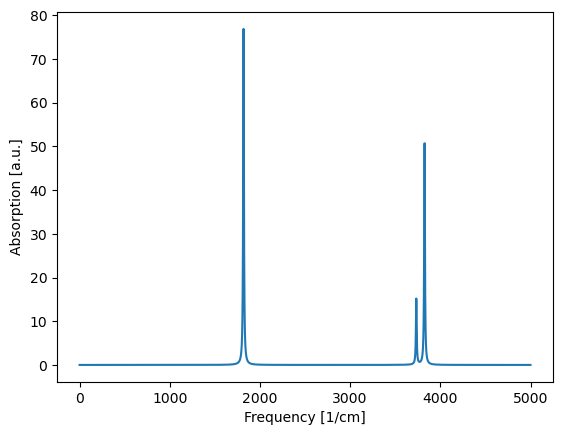

In [52]:
job_fr = pr.load('h2o_freq')

# Print the harmonic frequencies
freqs, ints, modes = job_fr.read_NMA()
print(freqs) # in 1/cm

# Plot the IR spectrum
job_fr.plot_IR_spectrum()

## Visualize the normal modes

We indeed get 3 eigenmodes:

In [56]:
# bending mode
job_fr.animate_nma_mode(0, amplitude=0.5, frames=12)

This mode corresponds to a frequency of 1817.7908 1/cm


NGLWidget(max_frame=11)

In [57]:
# symmetric stretching mode
job_fr.animate_nma_mode(1, amplitude=0.5, frames=12)

This mode corresponds to a frequency of 3733.0088 1/cm


NGLWidget(max_frame=11)

In [58]:
# anti-symmetric stretching mode
job_fr.animate_nma_mode(2, amplitude=0.5, frames=12)

This mode corresponds to a frequency of 3824.5732 1/cm


NGLWidget(max_frame=11)

We can also print the molecular orbitals and visualize them.

In [59]:
# Print the possible molecular orbitals
job_fr.print_MO()

#0: 	 Orbital energy =  -20.54682 	 Occ. = 2.0
#1: 	 Orbital energy =   -1.33367 	 Occ. = 2.0
#2: 	 Orbital energy =   -0.70085 	 Occ. = 2.0
#3: 	 Orbital energy =   -0.56739 	 Occ. = 2.0
#4: 	 Orbital energy =   -0.49840 	 Occ. = 2.0
#5: 	 Orbital energy =    0.14869 	 Occ. = 0.0
#6: 	 Orbital energy =    0.21535 	 Occ. = 0.0
#7: 	 Orbital energy =    0.56178 	 Occ. = 0.0
#8: 	 Orbital energy =    0.60250 	 Occ. = 0.0
#9: 	 Orbital energy =    1.00053 	 Occ. = 0.0
#10: 	 Orbital energy =    1.00433 	 Occ. = 0.0
#11: 	 Orbital energy =    1.10710 	 Occ. = 0.0
#12: 	 Orbital energy =    1.31544 	 Occ. = 0.0
#13: 	 Orbital energy =    1.50841 	 Occ. = 0.0
#14: 	 Orbital energy =    1.50875 	 Occ. = 0.0
#15: 	 Orbital energy =    1.71879 	 Occ. = 0.0
#16: 	 Orbital energy =    1.90212 	 Occ. = 0.0
#17: 	 Orbital energy =    2.23479 	 Occ. = 0.0
#18: 	 Orbital energy =    2.36529 	 Occ. = 0.0
#19: 	 Orbital energy =    2.60167 	 Occ. = 0.0
#20: 	 Orbital energy =    2.77758 	 Occ. = 0.0
#2

In [ ]:
# Visualize the molecular orbitals
view = job_fr.visualize_MO(4, particle_size=0.3, show_bonds=False)
# Make the whole density visible
view[1].update_surface(isolevel=1, color='blue', opacity=.3)
view[2].update_surface(isolevel=-1, color='red', opacity=.3)
view

Orbital energy =   -0.49840 	 Occ. = 2.0


<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Are the eigenfrequencies and eigenmodes in agreement with your expectation? </li>
<br>
<li>Can you identify which linear combination of atomic orbitals is predominantly present in each molecular orbital? </li>
</ol>
</div>